[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PerformanceEstimation/PEPit/blob/master/ressources/demo/PEPit_demo_extract_worst_case_examples.ipynb)

# PEPit : numerical identification of worst-case examples

This notebook provides:
- A simple example illustrating how to obtain a worst-case instance for **gradient descent** (when minimizing a smooth convex function) using the PEPit package.
- Four other examples illustrating how to obtain worst-case instances in other situations: with proximal operators, momentum, possibly non-convex functions, and primal-dual methods.

For a first demo of PEPit, including detailed installation, imports, and basic introductory steps, we refer to the introductory [demo](https://colab.research.google.com/github/bgoujaud/PEPit/blob/master/ressources/demo/PEPit_demo.ipynb) file.


This notebook considers the following four algorithms:
* [Example 1](#example1) : **gradient descent** for smooth convex minimization (1D examples).
* [Example 2](#example2) : the **fast iterative shrinkage-thresholding algorithm** (FISTA) for composite convex minimization (1D examples).
* [Example 3](#example3) : **gradient descent** for smooth possibly non-convex minimization (1D examples).
* [Example 4](#example4) : an **alternating projection algorithm** for finding a point in intersection of two convex sets (2D examples).
* [Example 5](#example5) : a primal-dual **proximal-point algorithm** for convex (possibly non-smooth) minimization (2D examples).
* [Example 6](#example6) : **gradient descent with exact line-search** for smooth strongly convex minimization (2D examples).

**Import a few necessary common Python packages (numpy, matplotlib)**

In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams.update({
    "mathtext.fontset": "cm",   # LaTeX font for rendering equations in plots
    "legend.fontsize": 12,
    "axes.labelsize": 14
})
import matplotlib.pyplot as plt

from math import sqrt

We re-implement some basic examples below. This is necessary as we will save the worst-case trajectories.

## Example 1 : gradient descent for smooth convex minimization <a class="anchor" id="example1"></a>

We consider the following convex minimization problem:
\begin{equation}
f_\star \triangleq \min_x f(x),
\end{equation}
where $f$ is $L$-smooth and convex.

For this example, we consider the problem of computing the smallest possible $\tau(n, L, \gamma)$ such that the following guarantee holds (for any initialization of the algorithm, and any $L$-smooth convex functions)
\begin{equation}
f(x_n)-f_\star \leqslant \tau(n, L, \gamma) \| x_0 - x_\star \|^2,
\end{equation}
where $x_n$ is the output of gradient descent with fixed step size $\gamma$, started from $x_0$, and where $x_\star$ is a minimizer of $f$.

#### Algorithm

Gradient descent with fixed step size $\gamma$ may be described as follows, for $t \in \{0,1, \ldots, n-1\}$
\begin{equation}
x_{t+1} = x_t - \gamma \nabla f(x_t).
\end{equation}


#### Low-dimensional worst-case examples

The solution to the PEP provides an example trajectory of points that would result in a worst-case convergence rate. In general, worst-case examples are non-unique in different ways: there are generally many trajectories of points that result in worst-case performance, and there are generally multiple different functions that can interpolate the same trajectory. Using a solution to the PEP, one can identify the dimension of a matching worst-case instance by inspection of the rank of the Gram matrix. More precisely, the rank of the Gram matrix corresponds to the dimension of the matching worst-case example (see, e.g., [here, Section 3.2](https://arxiv.org/pdf/1502.05666)).

PEPit contains a few heuristics to try to identify such low-dimensional worst-case instances, by searching for low-rank Gram matrices. There are two of them: the trace heuristic ($\ell_1$ on the eigenvalues) and the logdet heuristic---applying gradient descent on the logdet of the Gram matrix $G$, which corresponds to a reweighted $\ell_1$ on the eigenvalues of $G$. For both of them, we need to potentially leave some slack in the objective, which we fix here to `tol_dimension_reduction=1e-6`.

In [2]:
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction

L = 1
gamma = 1/L
n = 4
verbose = 1


# Instantiate PEP
problem = PEP()

# Declare a smooth strongly convex function
f = problem.declare_function(SmoothStronglyConvexFunction, L=L,mu=0)

# Then define the starting point x0 of the algorithm as well as corresponding gradient and function value g0 and f0
x0 = problem.set_initial_point()
g0, f0 = f.oracle(x0)

xs = f.stationary_point()
gs, fs = f.oracle(xs)

# Prepare empty lists for saving all datapoints
x_list = list()
g_list = list()
f_list = list()

# Run n steps of GD method with step-size gamma
gx, fx = g0, f0

x_list.append(x0)
g_list.append(g0)
f_list.append(f0)

for i in range(n):
    x_list.append(x_list[-1] - gamma * gx)
    gx, fx = f.oracle(x_list[-1])
    g_list.append(gx)
    f_list.append(fx)
    
# Set initial condition and performance metric
problem.set_initial_condition((x0-xs)**2 <= 1)
problem.set_performance_metric(f_list[-1] - fs)

# Solve the PEP
pepit_verbose = max(verbose, 0)
pepit_tau = problem.solve(verbose=pepit_verbose, dimension_reduction_heuristic="trace", tol_dimension_reduction=1e-6)



(PEPit) Setting up the problem: performance measure is the minimum of 1 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 1 function(s)
			Function 1 : Adding 30 scalar constraint(s) ...
			Function 1 : 30 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 0 function(s)
(PEPit) Setting up the problem: size of the Gram matrix: 7x7
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (wrapper:cvxpy, solver: MOSEK); optimal value: 0.05555555533809005
(PEPit) Postprocessing: 2 eigenvalue(s) > 4.671409968645035e-08 before dimension reduction
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (solver: MOSEK); objective value: 0.05555455530199128
(PEPit) Postprocessing: 1 eigenvalue(s) > 1.697387044378287e-09 after dimens

As we can see from the output, PEPit identified a low-rank matrix where all eigenvalues (except one) is approximately equal to 0. This corresponds to a single-dimensional worst-case example.
In order to evaluate and plot a worst-case trajectory, we use the `eval` function on the iterates, their gradients, and function values. Since we want to visualize the worst-case in 1D, we trim the dimension to only the first components.

In [3]:
# Evaluate the iterations:

x_list_evaluated = [x.eval()[0] for x in x_list] # [0] is because we are interested in largest component only
g_list_evaluated = [g.eval()[0] for g in g_list] # same
f_list_evaluated = [f.eval() for f in f_list]

# Evaluate specific points (for better visualization later)
xs_evaluated = xs.eval()[0] # x*
gs_evaluated = gs.eval()[0] # g(x*)=0
fs_evaluated = fs.eval() # f(x*)

x0_evaluated = x0.eval()[0] # x0
g0_evaluated = g0.eval()[0] # g(x0)
f0_evaluated = f0.eval() # f(x0)

Now, using the list of iterates, we can simply plot the trajectory (in terms of $(x,f(x))$ as follows: 

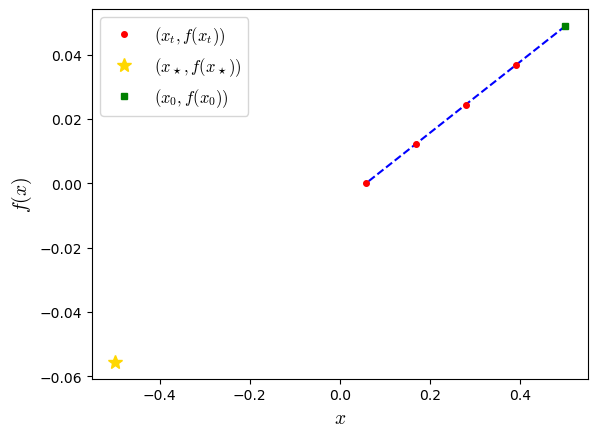

In [4]:
plt.plot(x_list_evaluated, f_list_evaluated, '.--', color='blue')

plt.plot(x_list_evaluated, f_list_evaluated, marker='.', color='red',  linestyle='none', markersize=8, label='$(x_t,f(x_t))$')
plt.plot(xs_evaluated, fs_evaluated, marker='*', color='gold', linestyle='none', markersize=10, label=r'$(x_\star,f(x_\star))$')
plt.plot(x0_evaluated, f0_evaluated, marker='s', color='green', linestyle='none', markersize=5, label=r'$(x_0,f(x_0))$')


plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')

plt.show()

The last plot is giving a partial picture of what a worst-case function might look like: the function is evaluated only at a few points (iterates & an optimal point).

For this reason, we provide a few tools that allows extrapolating within certain classes of functions. This is done via the "interpolator" classes (that internally formulate the interpolation problems for a few classes).

The interpolator that corresponds to the PEP under consideration can be obtained (when implemented for the corresponding class) as follows (possibly with a few options):

In [5]:
feval = f.get_interpolator()

Now, we can evaluate an interpolating function on a grid of points "x_test" around the iterates and the solution.

In [6]:
# Create a grid of points where an interpolating function should be computed:
nb_pts_grid = 100
x_min = np.min([x0_evaluated,xs_evaluated])
x_max = np.max([x0_evaluated,xs_evaluated])
x_test = np.linspace(x_min,x_max,nb_pts_grid)

# Use the interpolation tools: evaluate a function using the "feval" interpolator on the grid:
fx_test = np.zeros(x_test.shape)
for i in range(len(x_test)):
    fx_test[i] = feval(np.array([x_test[i]]))
    print(f'{i + 1} / {len(x_test)} grid points computed', end='\r', flush=True)

... which we can now plot!

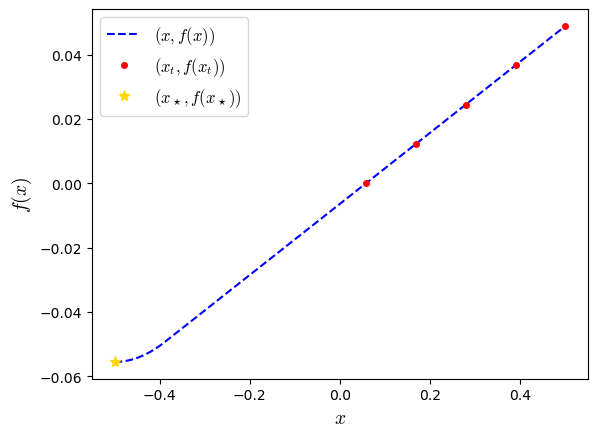

In [7]:
#plt.plot(x_list_evaluated[::1,], f_list_evaluated, '.--', color='blue')
plt.plot(x_test, fx_test, '--', color='blue', label='$(x,f(x))$')
plt.plot(x_list_evaluated, f_list_evaluated, marker='.', color='red',  linestyle='none', markersize=8, label='$(x_t,f(x_t))$')
plt.plot(xs_evaluated, fs_evaluated, marker='*', color='gold', linestyle='none', markersize=8, label=r'$(x_\star,f(x_\star))$')


plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')

plt.show()

We observe a trajectory that looks like a type of Huber loss function, as predicted by the proof of Theorem 3.2 from [this paper](https://arxiv.org/pdf/1206.3209).

## Example 2 : FISTA for composite convex minimization <a class="anchor" id="example2"></a>

We consider the following convex minimization problem:
\begin{equation}
F_\star \triangleq \min_x f(x)+h(x),
\end{equation}
where $f$ is $L$-smooth and convex, and where $h$ is convex (closed, proper) with a proximal operator readily available.

For this example, we consider the problem of computing the smallest possible $\tau(n, L)$ such that the following guarantee holds (for any initialization of the algorithm, and any $L$-smooth convex function)
\begin{equation}
F(x_n)-F_\star \leqslant \tau(n, L) \| x_0 - x_\star \|^2,
\end{equation}
where $x_n$ is the output of the FISTA initiated at $x_0$, and where $x_\star$ is a minimizer of $F$.

#### Algorithm

The iterates of FISTA are described as (for $t \in \{0,1, \ldots, n-1\}$)
$$
\begin{aligned}
            \lambda_{t+1}  & = &\frac{1 + \sqrt{4\lambda_t^2 + 1}}{2}\\
            x_t & = &\mathrm{argmin}_x \left\{h(x)+\frac{L}{2}\left\|x-\left(y_t - \frac{1}{L} \nabla f(y_t)\right)\right\|^2 \right\}\\
            y_{t+1} & = & x_t + \frac{\lambda_t-1}{\lambda_{t+1}} (x_t-x_{t-1}).
\end{aligned}
$$

Let us first start by importing all the necessary packages for the implementation in PEPit (this is done [there](https://pepit.readthedocs.io/en/0.4.0/examples/b.html#accelerated-proximal-gradient-a-k-a-fista), which we use below).

In [8]:
from math import sqrt
from PEPit import PEP
from PEPit.functions import SmoothConvexFunction
from PEPit.functions import ConvexFunction
from PEPit.primitive_steps import proximal_step

The following lines adapt the previous code to the study of FISTA:

In [9]:
# Parameters / options for the study:
verbose = 1  # verbose
n = 3 # number of iterations
L = 1 # Lipschitz constant

# Performance estimation problem (PEP) formulation:

# Instantiate PEP
problem = PEP()

# Declare a strongly convex smooth function and a convex function
f = problem.declare_function(SmoothConvexFunction, L=L)
h = problem.declare_function(ConvexFunction)
F = f + h

# Start by defining an optimal point xs = x_* and its function value Fs = F(x_*)
xs = F.stationary_point()
Fs = F(xs)
gs, fs = f.oracle(xs) # this is g(xs)=f'(x_*)
ss, hs = -gs, Fs - fs # this is s(xs) \in \partial h(x_*)  and hs = Fs - fs

# Create empty lists for saving a worst-case trajectory
y_list = list() # list of points where we will evaluate f() and its gradient
g_list = list() # list of evaluated gradients of f() at y's
f_list = list() # list of evaluated f() at y's
x_list = list() # list of outputs of the proximal operator
s_list = list() # list of evaluated subgradients of h() at x's (outputs of prox)
h_list = list() # list of evaluated h() at x's (outputs of prox)

# Then define a starting point x0
x0 = problem.set_initial_point()
g0, f0 = f.oracle(x0)
# Set the initial constraint that is the distance between x0 and x^*
problem.set_initial_condition((x0 - xs) ** 2 <= 1)

# Compute n steps of FISTA starting from x0    	
x_new = x0
y = x0
lam = 1
for i in range(n):
    # update momentum parameters
    lam_old = lam
    lam = (1 + sqrt(4 * lam_old ** 2 + 1)) / 2
    
    # save old point for momentum
    x_old = x_new
    
    # evaluate gradient at y + save corresponding values
    gy, fy = f.oracle(y)
    y_list.append(y)
    g_list.append(gy)
    f_list.append(fy)
    
    # perform a proximal-gradient step
    x_new, sx_new, hx_new = proximal_step(y - 1 / L * gy, h, 1 / L)
    
    # save outputs/subgradient of h() at x (output of prox)
    x_list.append(x_new)
    s_list.append(sx_new)
    h_list.append(hx_new)
    
    y = x_new + (lam_old - 1) / lam * (x_new - x_old)

# Since we evaluate the performance of the algorithm at x_n, we add it to the y_list (list of points at which f() is evaluated)
gx, fx = f.oracle(x_new)
y_list.append(x_new)
g_list.append(gx)
f_list.append(fx) 

# Set the performance metric to the function value accuracy
problem.set_performance_metric((fx + hx_new) - Fs)

# Solve the PEP
pepit_verbose = max(verbose, 0)
pepit_tau = problem.solve(verbose=pepit_verbose, dimension_reduction_heuristic="trace", tol_dimension_reduction=1e-6)

(PEPit) Setting up the problem: performance measure is the minimum of 1 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 2 function(s)
			Function 1 : Adding 20 scalar constraint(s) ...
			Function 1 : 20 scalar constraint(s) added
			Function 2 : Adding 12 scalar constraint(s) ...
			Function 2 : 12 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 0 function(s)
(PEPit) Setting up the problem: size of the Gram matrix: 10x10
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (wrapper:cvxpy, solver: MOSEK); optimal value: 0.07617878654566244
(PEPit) Postprocessing: 3 eigenvalue(s) > 7.475733125793583e-08 before dimension reduction
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (solver: MOSEK); objective valu

Let us clean and evaluate the different lists, in order to plot the corresponding functions:

In [10]:
# Evaluation of the trajectories:
y_list_evaluated = [y.eval()[0] for y in y_list] # centered iterates (evaluations of f() )
x_list_evaluated = [x.eval()[0] for x in x_list] # centered iterates (evaluations of h() )

g_list_evaluated = [g.eval()[0] for g in g_list] # gradient values for f
s_list_evaluated = [s.eval()[0] for s in s_list] # gradient values for h

f_list_evaluated = [f.eval() for f in f_list] # centered function values
h_list_evaluated = [h.eval() for h in h_list] # centered function values

# Evaluations at the optimal point:
xs_evaluated = xs.eval()[0] # x*
gs_evaluated = gs.eval()[0] # g(x*)=0
fs_evaluated = fs.eval() # f(x*)
ss_evaluated = -gs_evaluated # s(x*) \in\partial h(x*)
hs_evaluated = Fs.eval()

# Evaluations at x0
x0_evaluated = x0.eval()[0] # x*
g0_evaluated = g0.eval()[0] # g(x*)=0
f0_evaluated = f0.eval() # f(x*)

Let us now plot the iterates on the two functions (in terms of $(y,f(y))$ and $(x,f(x))$, side to side:

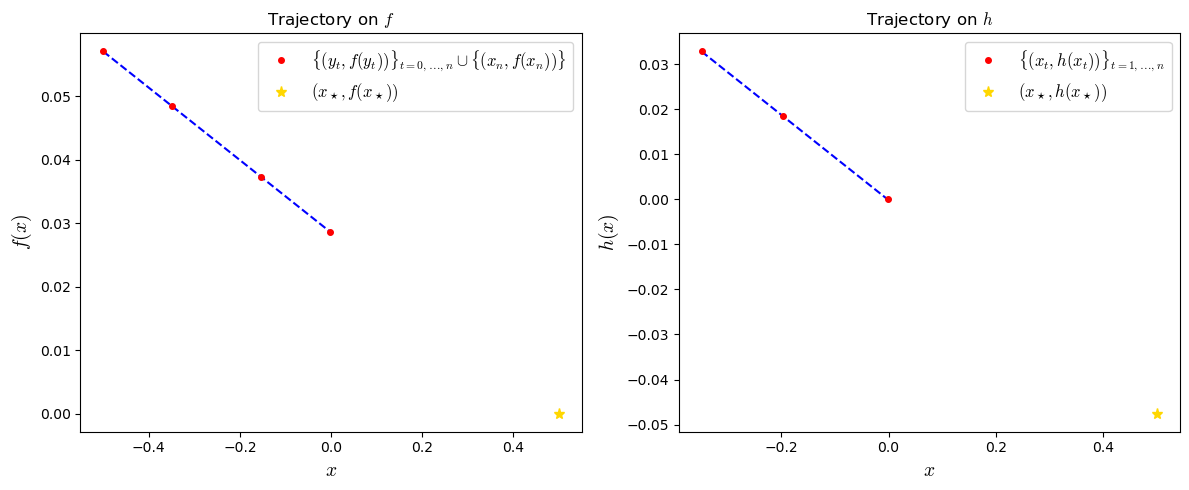

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --------------------------
# LEFT: trajectory evaluated on f()
# --------------------------
ax1.plot(y_list_evaluated, f_list_evaluated, '.--', color='blue')
ax1.plot(y_list_evaluated, f_list_evaluated, marker='.', color='red',
         linestyle='none', markersize=8,
         label='$\\{(y_t,f(y_t))\\}_{t=0,\\ldots,n} \\cup \\{(x_n,f(x_n))\\}$')
ax1.plot(xs_evaluated, fs_evaluated, marker='*', color='gold',
         linestyle='none', markersize=8,
         label='$(x_\\star,f(x_\\star))$')

ax1.set_xlabel('$x$')
ax1.set_ylabel('$f(x)$')
ax1.legend()
ax1.set_title('Trajectory on $f$')


# --------------------------
# RIGHT: trajectory evaluated on h()
# --------------------------
ax2.plot(x_list_evaluated, h_list_evaluated, '.--', color='blue')
ax2.plot(x_list_evaluated, h_list_evaluated, marker='.', color='red',
         linestyle='none', markersize=8,
         label='$\\{(x_t,h(x_t))\\}_{t=1,\\ldots,n}$')
ax2.plot(xs_evaluated, hs_evaluated, marker='*', color='gold',
         linestyle='none', markersize=8,
         label='$(x_\\star,h(x_\\star))$')

ax2.set_xlabel('$x$')
ax2.set_ylabel('$h(x)$')
ax2.legend()
ax2.set_title('Trajectory on $h$')

plt.tight_layout()
plt.show()


This is already quite informative, but arguably not enough. Can we easily recover a pair of functions interpolating through those points? Lets interpolate an example of a worst-case function $F$ by computing the two functions $f$ and $g$ separately, again using the `interpolator` tool, which we instantiate below.

In [12]:
feval = f.get_interpolator()
heval = h.get_interpolator()

In [13]:
# Grid parameters
nb_pts_grid = 50 
margin = .2 # plot the interpolated function slightly outside the convex hull of iterates/optimal point

# Create a grid of points where an interpolating function for f() should be computed:
y_min = np.min([np.min(y_list_evaluated),xs_evaluated])
y_max = np.max([np.max(y_list_evaluated),xs_evaluated])
y_test = np.linspace(y_min-margin,y_max+margin,nb_pts_grid)

fy_test = np.zeros(y_test.shape)
for i in range(len(y_test)):
    fy_test[i] = feval(np.array([y_test[i]]))
    print(f'{i + 1} / {len(y_test)} grid points computed', end='\r', flush=True)

In [14]:
# Create a grid of points where an interpolating function for h() should be computed:
nb_pts_grid = 50
x_min = np.min([np.min(x_list_evaluated),xs_evaluated])
x_max = np.max([np.max(x_list_evaluated),xs_evaluated])
x_test = np.linspace(x_min-margin,x_max+margin,nb_pts_grid)

hx_test = np.zeros(x_test.shape)
for i in range(len(x_test)):
    hx_test[i] = heval(np.array([x_test[i]]))
    print(f'{i + 1} / {len(x_test)} grid points computed', end='\r', flush=True)

The computed worst-case examples are thus as below:

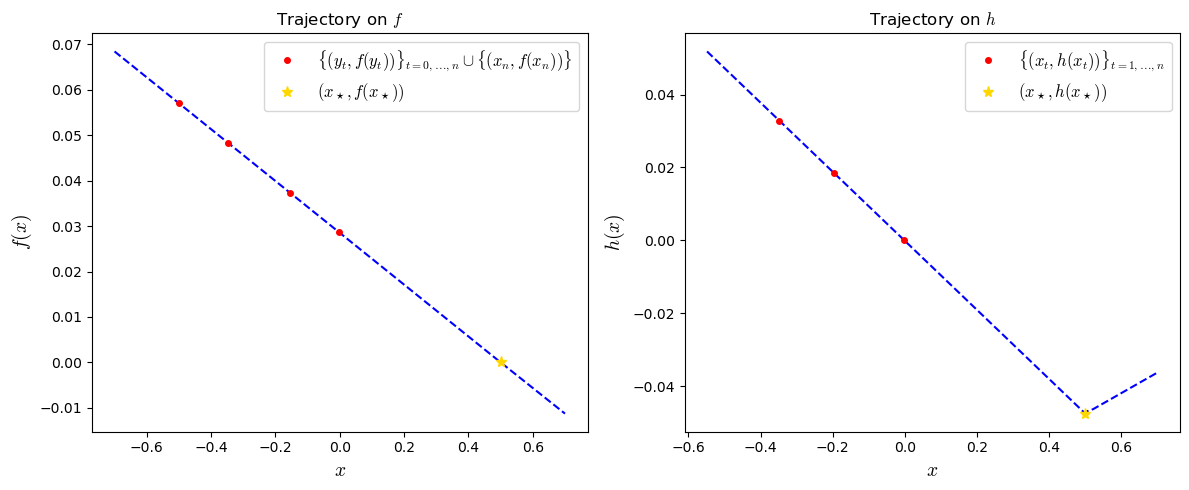

In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --------------------------
# LEFT: trajectory evaluated on f()
# --------------------------
ax1.plot(y_test, fy_test, '--', color='blue')
ax1.plot(y_list_evaluated, f_list_evaluated, marker='.', color='red',
         linestyle='none', markersize=8,
         label='$\\{(y_t,f(y_t))\\}_{t=0,\\ldots,n} \\cup \\{(x_n,f(x_n))\\}$')
ax1.plot(xs_evaluated, fs_evaluated, marker='*', color='gold',
         linestyle='none', markersize=8,
         label='$(x_\\star,f(x_\\star))$')

ax1.set_xlabel('$x$')
ax1.set_ylabel('$f(x)$')
ax1.legend()
ax1.set_title('Trajectory on $f$')


# --------------------------
# RIGHT: trajectory evaluated on h()
# --------------------------
ax2.plot(x_test, hx_test, '--', color='blue')
ax2.plot(x_list_evaluated, h_list_evaluated, marker='.', color='red',
         linestyle='none', markersize=8,
         label='$\\{(x_t,h(x_t))\\}_{t=1,\\ldots,n}$')
ax2.plot(xs_evaluated, hs_evaluated, marker='*', color='gold',
         linestyle='none', markersize=8,
         label='$(x_\\star,h(x_\\star))$')

ax2.set_xlabel('$x$')
ax2.set_ylabel('$h(x)$')
ax2.legend()
ax2.set_title('Trajectory on $h$')

plt.tight_layout()
plt.show()

So we observe that the worst-case is achieved already when $f$ is linear and when $h$ is a $\ell_1$-shaped (in fact, a simple worst-case example of $h$ is just the indicator function, see, e.g., [this paper (Section 4.2)](https://arxiv.org/pdf/1512.07516) or [Yoel Drori's thesis, Section 2.8](https://www.researchgate.net/profile/Yoel-Drori/publication/303895929_Contributions_to_the_Complexity_Analysis_of_Optimization_Algorithms/links/575b19f008ae9a9c95519686/Contributions-to-the-Complexity-Analysis-of-Optimization-Algorithms.pdf) for the related projected gradient method).

## Example 3 : gradient descent for potentially non-convex minimization <a class="anchor" id="example3"></a>

We consider the following convex minimization problem:
\begin{equation}
f_\star \triangleq \min_x f(x),
\end{equation}
where $f$ is $L$-smooth (and potentially non-convex).

For this example, we consider the problem of computing the smallest possible $\tau(n, L, \mu, \gamma)$ such that the following guarantee holds (for any initialization of the algorithm, and any $L$-smooth function)
\begin{equation}
\min_{0\leq t\leq n} \|\nabla f(x_t)\|^2 \leqslant \tau(n, L, \gamma) (f(x_0)-f(x_\star)),
\end{equation}
where $x_t$ are the iterates gradient descent with step size $\gamma$, started from $x_0$:
\begin{equation}
x_{t+1} = x_t - \gamma \nabla f(x_t),
\end{equation}
and where $x_\star$ is a stationary point such that $f(x_\star)\leq f(x_t)$ for all $t=0,1,\ldots,n$.


In [16]:
from PEPit import PEP
from PEPit.functions import SmoothFunction

L = 1
n = 3
gamma = .95/L
verbose = 1


# Instantiate PEP
problem = PEP()

# Declare a smooth strongly convex function
f = problem.declare_function(SmoothFunction, L=L)

# Then define the starting point x0 of the algorithm as well as corresponding gradient and function value g0 and f0
x0 = problem.set_initial_point()
g0, f0 = f.oracle(x0)

xs = f.stationary_point()
gs, fs = f.oracle(xs)

# Run n steps of GD method with step-size gamma
x_list = list()
g_list = list()
f_list = list()
gx, fx = g0, f0

x_list.append(x0)
f_list.append(f0)
g_list.append(g0)

for i in range(n):
    # Set the performance metric to the minimum of the gradient norm over the iterations
    problem.set_performance_metric(gx**2)
    f.add_constraint(fs <= fx - 1/2/L * gx**2)
    x_list.append(x_list[-1] - gamma * gx)
    gx, fx = f.oracle(x_list[-1])
    f_list.append(fx)
    g_list.append(gx)
problem.set_performance_metric(gx**2)
f.add_constraint(fs <= fx - 1/2/L * gx**2)

# Set initial condition
problem.set_initial_condition( f0 - fs == 1)

# Solve the PEP
pepit_verbose = max(verbose, 0)
pepit_tau = problem.solve(verbose=pepit_verbose, dimension_reduction_heuristic="logdet3", tol_dimension_reduction=1e-6)

(PEPit) Setting up the problem: performance measure is the minimum of 4 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 1 function(s)
			Function 1 : Adding 20 scalar constraint(s) ...
			Function 1 : 20 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 1 function(s)
			Function 1 : Adding 4 scalar constraint(s) ...
			Function 1 : 4 scalar constraint(s) added
(PEPit) Setting up the problem: size of the Gram matrix: 6x6
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (wrapper:cvxpy, solver: MOSEK); optimal value: 0.3740939827808659
(PEPit) Postprocessing: 3 eigenvalue(s) > 2.4421029352655765e-07 before dimension reduction
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (solver: MOSEK); objective value: 0

Again: PEPit claims to have found a 1D counterexample, so we focus on the first coordinates of the output.

In [17]:
# Evaluate the coordinate, gradient, and function values
x_list_evaluated = [x.eval()[0] for x in x_list]
g_list_evaluated = [g.eval()[0] for g in g_list]
f_list_evaluated = [f.eval() for f in f_list]

# Evaluate a specific point (x*):
xs_evaluated = xs.eval()[0] # x*
fs_evaluated = fs.eval() # f(x*)
gs_evaluated = gs.eval()[0] # g(x*)

Let us now obtain the interpolator and use it to visualize a worst-case instance!

In [18]:
# get an interpolator
feval = f.get_interpolator()


# Create a grid of points where an interpolating function for f() should be computed:
nb_pts_grid = 100 # number of points on the grid
margin = .2 # extrapolate outside only evaluated points

x_min = np.min([np.min(x_list_evaluated),xs_evaluated])
x_max = np.max([np.max(x_list_evaluated),xs_evaluated])
x_test = np.linspace(x_min-margin,x_max+margin,nb_pts_grid)

fx_test = np.zeros(x_test.shape)
# Interpolate on the grid!
for i in range(len(x_test)):
    fx_test[i] = feval(np.array([x_test[i]]))
    print(f'{i + 1} / {len(x_test)} grid points computed', end='\r', flush=True)


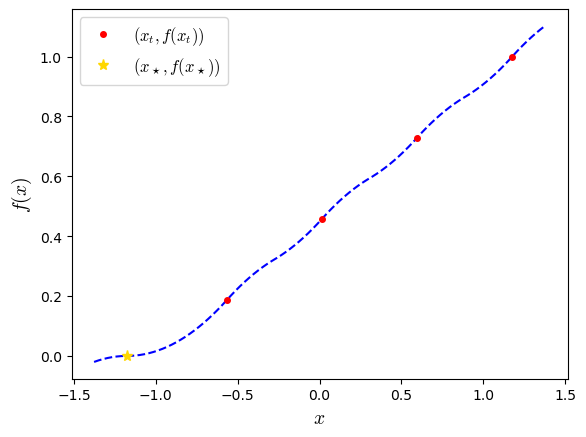

In [19]:
plt.plot(x_test, fx_test, '--', color='blue')
plt.plot(x_list_evaluated, f_list_evaluated, marker='.', color='red',  linestyle='none', markersize=8, label=r'$(x_t,f(x_t))$')
plt.plot(xs_evaluated, fs_evaluated, marker='*', color='gold', linestyle='none', markersize=8, label=r'$(x_\star,f(x_\star))$')


plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')

plt.show()

A natural question now is whether this interpolator is actually unique. In fact, it is not in general. In PEPit, the default interpolator is often the one that creates the *lowest possible* interpolating function (the one that results in points with the *smallest possible function value*), but one can configure the interpolator to do the opposite (as we shall see in the next example).

In [20]:
# get an interpolator
feval = f.get_interpolator(options='highest')


# Create a grid of points where an interpolating function for f() should be computed:
nb_pts_grid = 100 # number of points on the grid
margin = .2 # extrapolate outside only evaluated points

x_min = np.min([np.min(x_list_evaluated),xs_evaluated])
x_max = np.max([np.max(x_list_evaluated),xs_evaluated])
x_test = np.linspace(x_min-margin,x_max+margin,nb_pts_grid)

fx_test = np.zeros(x_test.shape)
# Interpolate on the grid!
for i in range(len(x_test)):
    fx_test[i] = feval(np.array([x_test[i]]))
    print(f'{i + 1} / {len(x_test)} grid points computed', end='\r', flush=True)


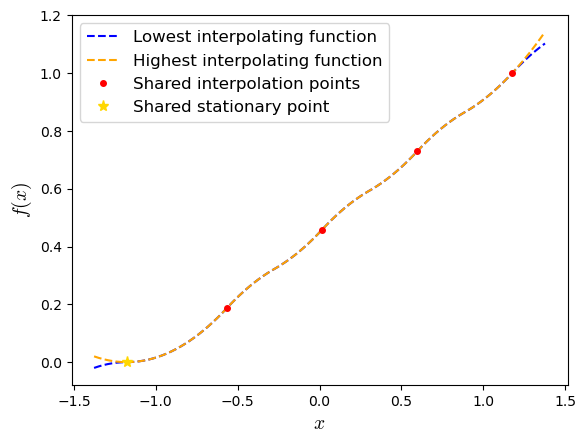

In [21]:
feval_lowest = f.get_interpolator()
fx_test_lowest = np.array([feval_lowest(np.array([x])) for x in x_test])

plt.plot(x_test, fx_test_lowest, '--', color='blue', label='Lowest interpolating function')
plt.plot(x_test, fx_test, '--', color='orange', label='Highest interpolating function')
plt.plot(x_list_evaluated, f_list_evaluated, marker='.', color='red',  linestyle='none', markersize=8, label='Shared interpolation points')
plt.plot(xs_evaluated, fs_evaluated, marker='*', color='gold', linestyle='none', markersize=8, label='Shared stationary point')


plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')

plt.show()

This is slightly different from the previous example (particularly outside of the range $[x_\star,x_0]$).

## Example 4 : alternate projections for finding a point in the intersection of two convex sets <a class="anchor" id="example4"></a>

In this example, we model the problem of finding a point in the intersection of two convex sets:
\begin{equation}
\text{Find } x\in\mathbb{R}^d: x\in Q_1\cap Q_2 \quad \Leftrightarrow \quad \min_{x\in\mathbb{R}^d} f_1(x)+f_2(x),
\end{equation}
with $f_1,f_2$ respectively the indicator functions for $Q_1$ and $Q_2$, which are closed convex sets.

More precisely, we investigate low-dimensional examples achieving a worst-case ratio for the criterion:
\begin{equation}
\frac{\|\mathrm{Proj}_{Q_1}(x_t)-\mathrm{Proj}_{Q_2}(x_t)\|^2}{\|x_0-x_\star\|^2}
\end{equation}

where $x_t$ ($t\in\{0,\ldots,n\}$) are generated by the alternate projection method

\begin{equation}
x_{t+1} = \mathrm{Proj}_{Q_2}\left(\mathrm{Proj}_{Q_1}\left(x_t\right)\right).
\end{equation}


We start by importing a few functions.

In [22]:
from PEPit import PEP
from PEPit.functions import ConvexIndicatorFunction
from PEPit.primitive_steps import proximal_step

In [23]:
# Parameters / options for the study:
verbose = 1  # verbose
n = 5 # number of iterations


# Instantiate PEP
problem = PEP()

f1 = problem.declare_function(ConvexIndicatorFunction) # indicator for Q1
f2 = problem.declare_function(ConvexIndicatorFunction) # indicator for Q2
func = f1 + f2 # indicator for the intersection

# x* is a point in the intersection
xs = func.stationary_point()

# Then define the starting point x0 of the algorithm
x0 = problem.set_initial_point()

# Run the alternate projection method
z_list = list() # list of points after projections
x = x0
for i in range(n):
    y, _, _ = proximal_step(x, f1, 1)
    z_list.append(y)
    x, _, _ = proximal_step(y, f2, 1)
    z_list.append(x)

# Set the performance metric to the distance between x and xs
problem.set_performance_metric((y-x)**2)
problem.set_initial_condition((x0-xs)**2==1)


# Solve the PEP
pepit_tau = problem.solve(verbose=verbose, dimension_reduction_heuristic='logdet2')

(PEPit) Setting up the problem: performance measure is the minimum of 1 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 2 function(s)
			Function 1 : Adding 36 scalar constraint(s) ...
			Function 1 : 36 scalar constraint(s) added
			Function 2 : Adding 36 scalar constraint(s) ...
			Function 2 : 36 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 0 function(s)
(PEPit) Setting up the problem: size of the Gram matrix: 13x13
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (wrapper:cvxpy, solver: MOSEK); optimal value: 0.04330493475312516
(PEPit) Postprocessing: 4 eigenvalue(s) > 1.3104692559444046e-07 before dimension reduction
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (solver: MOSEK); objective val

As PEPit claims to have found a 2D example, we only visualize the first 2 coordinates of the identified worst-case instance.

In [24]:
# Evaluation at the optimal point:
xs_evaluated = xs.eval()[0:2] # x*

# Evaluation of the trajectories (centered around x* = 0 for simplicity)
z_list_evaluated = [z.eval()[0:2]-xs_evaluated[0:2] for z in z_list] # centered iterates

xs_evaluated = xs_evaluated - xs_evaluated # should be zero 

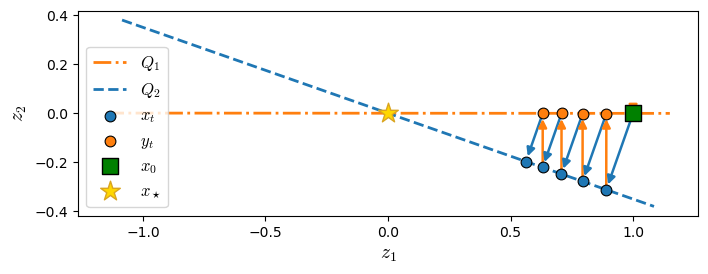

In [ ]:
z = np.array(z_list_evaluated)
x_points = np.vstack([x0.eval()[0:2] - xs.eval()[0:2], z[1::2]])
y_points = z[::2]
x_star = np.zeros(2)

# The worst-case sets are lines: find out their angle from the solution
q1_dir = y_points[np.argmax(np.sum(y_points**2, axis=1))]
q1_dir = q1_dir / np.linalg.norm(q1_dir)
q2_dir = x_points[1:][np.argmax(np.sum(x_points[1:]**2, axis=1))]
q2_dir = q2_dir / np.linalg.norm(q2_dir)

extent = 1.15 * np.max(np.abs(np.vstack([x_points, y_points, x_star])))
t = np.linspace(-extent, extent, 200)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t * q1_dir[0], t * q1_dir[1], '-.', color='tab:orange', lw=2, label=r'$Q_1$')
ax.plot(t * q2_dir[0], t * q2_dir[1], '--', color='tab:blue', lw=2, label=r'$Q_2$')

steps = [step for k in range(len(y_points))
         for step in ((x_points[k], y_points[k], 'tab:orange'),
                      (y_points[k], x_points[k + 1], 'tab:blue'))]
for i, (start, end, color) in enumerate(steps):
    if not np.allclose(start, end):
        ax.annotate('', xy=end, xytext=start,
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=1.8, mutation_scale=12,
                                    shrinkA=0, shrinkB=4),
                    zorder=len(steps) - i)

y_plot = y_points[1:] if np.allclose(y_points[0], x_points[0]) else y_points
ax.scatter(x_points[1:, 0], x_points[1:, 1], color='tab:blue', s=60, edgecolors='black', linewidths=0.8, label=r'$x_t$', zorder=20)
ax.scatter(y_plot[:, 0], y_plot[:, 1], color='tab:orange', s=60, edgecolors='black', linewidths=0.8, label=r'$y_t$', zorder=20)
ax.scatter(*x_points[0], marker='s', color='green', s=120, edgecolors='black', linewidths=1.0, label=r'$x_0$', zorder=21)
ax.scatter(*x_star, marker='*', color='gold', s=220, edgecolors='goldenrod', linewidths=1.0, label=r'$x_\star$', zorder=21)

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
ax.set_aspect('equal', adjustable='box')
ax.legend()

plt.show()

We observe a nice alternate projection between two hyperplanes! (and tuning the angle between the hyperplanes suffices to obtain the worst-case estimate)

## Example 5 : primal-dual proximal point for convex minimization <a class="anchor" id="example5"></a>

For this last example, we consider again the problem of minimizing a sum:
\begin{equation}
\min_{x\in\mathbb{R}^d} f(x)+h(x)
\end{equation}
where both $f$ and $h$ are closed convex and proper, and we assume $\exists x_\star,y_\star$ (KKT point): $-y_\star\in\partial f(x_\star),\, x_\star\in\partial h^*(y_\star)$.
    
We study the primal-dual (PD) proximal-point algorithm for solving such problems: 
\begin{align}
(y_{k+1},x_{k+1})=\underset{y\in\mathbb{R}^d}{\mathrm{argmax}}\,\,\underset{x\in\mathbb{R}^d}{\mathrm{argmin}} \Bigl\{f(x)-h^*(y)+\langle y,\, x\rangle +\tfrac1{2\alpha} \|x-x_k\|^2-\tfrac1{2\alpha} \|y-y_k\|^2 \Bigl\}
\end{align}
and we inspect guarantees of the form (for some elements of $\partial f$ and $\partial h^*$)
\begin{equation}
\frac{\|g_N+y_N\|^2 + \|x_N-s_N\|^2}{\|x_0 - x_\star\|^2+\|y_0-y_\star\|^2}\leq \tau(N,\alpha)
\end{equation}
with $g_N\in\partial f(x_N)$ and $s_N\in\partial h^*(y_N)$.

To study this algorithm, we first import some necessary functions, followed by an implementation of the primal-dual proximal step in PEPit:

In [26]:
from PEPit import PEP
from PEPit.point import Point
from PEPit.expression import Expression
from PEPit.functions import ConvexFunction
import numpy as np

def PD_proximal_step(x0,lambda0, f, g, alpha):
    x1 = Point()
    lambda1 = Point()
    
    # subgradients
    pf_x1 = (x0-x1)/alpha-lambda1
    pg_lambda1 = (lambda0-lambda1)/alpha+x1
    
    fx1 = Expression()
    glambda1 = Expression()
    
    f.add_point((x1, pf_x1, fx1))
    g.add_point((pg_lambda1, lambda1, glambda1))

    return x1, lambda1, pf_x1, pg_lambda1

# helper function: evaluation of conjugate
def evaluate_conjugate(lam,f):
    x = Point()
    fx = Expression()
    f.add_point((x, lam, fx))
    fconj = lam*x - fx
    return fconj

In [27]:
n = 20 # number of iterations
alpha = n * [1] # step sizes
verbose = 1 # verbose mode


# PEP:
problem = PEP()

# Problem setup
f = problem.declare_function(ConvexFunction, reuse_gradient=True)
g = problem.declare_function(ConvexFunction, reuse_gradient=True)
F = f+g

# Optimal primal and dual solutions
xs = F.stationary_point()
ys = -f.gradient(xs)

# Starting point of the algorithm
x0 = problem.set_initial_point()
y0 = problem.set_initial_point()


# Compute n steps of the proximal method starting from x0
x_list = list()
y_list = list()
x_list.append(x0)
y_list.append(y0)

x = x0
y = y0
for i in range(n):
    x, y, df_xk, dg_lambdak = PD_proximal_step(x, y, f, g, alpha[i])
    x_list.append(x)
    y_list.append(y)

# Set initial condition (distance to a solution)
problem.set_initial_condition((x0 - xs) ** 2 + (y0 - ys) ** 2 <= 1)

# Set performance metric: KKT residual
problem.set_performance_metric((df_xk+y) ** 2 + (x - dg_lambdak) ** 2)

# Solve the PEP
pepit_tau = problem.solve(verbose=verbose, dimension_reduction_heuristic="logdet2")

(PEPit) Setting up the problem: performance measure is the minimum of 1 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 2 function(s)
			Function 1 : Adding 420 scalar constraint(s) ...
			Function 1 : 420 scalar constraint(s) added
			Function 2 : Adding 420 scalar constraint(s) ...
			Function 2 : 420 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 0 function(s)
(PEPit) Setting up the problem: size of the Gram matrix: 44x44
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (wrapper:cvxpy, solver: MOSEK); optimal value: 0.018867672537960456
(PEPit) Postprocessing: 6 eigenvalue(s) > 9.273341021631384e-08 before dimension reduction
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (solver: MOSEK); objective

PEPit claims to have found a 2D counter-example, so let us only visualize the first two coordinates.

In [28]:
# Evaluate specific point (a solution)
xs_evaluated = xs.eval()[0:2] # x*
ys_evaluated = ys.eval()[0:2] # y*

# Evaluate the list of iterates (centered around the solution above, for simplificty)
x_list_evaluated = [x.eval()[0:2]-xs_evaluated for x in x_list] # centered iterates
xs_evaluated = xs_evaluated - xs_evaluated # should be zero 
y_list_evaluated = [y.eval()[0:2]-ys_evaluated for y in y_list] # centered iterates
ys_evaluated = ys_evaluated - ys_evaluated # should be zero 

Now, let us plot a worst-case trajectory!

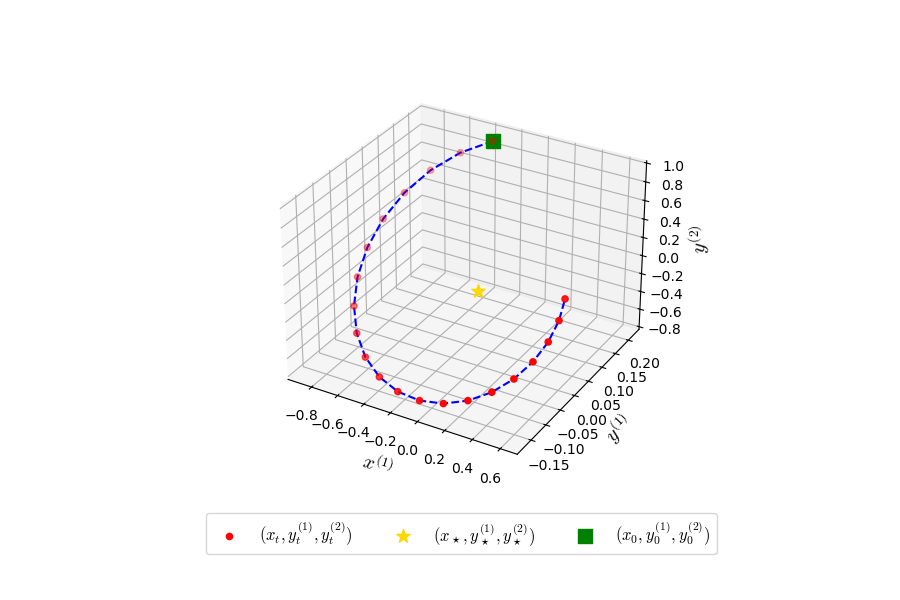

In [29]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib widget
plt.ion()  # <-- this enables rotation


import numpy as np

# Convert the list of 2D vectors into two arrays x1, x2
x_array = np.array(x_list_evaluated) 
x1 = x_array[:, 0]
x2 = x_array[:, 1]
# Convert the list of 2D vectors into two arrays y1, y2
y_array = np.array(y_list_evaluated)
y1 = y_array[:, 0]
y2 = y_array[:, 1]

# Worst-case point (xs_evaluated is a 2D vector)
xs = np.array(xs_evaluated)
xs1, xs2 = xs[0], xs[1]
# Worst-case point (ys_evaluated is a 2D vector)
ys = np.array(ys_evaluated)
ys1, ys2 = ys[0], ys[1]

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

# Blue line (trajectory)
ax.plot(x1, y1, y2, '--', color='blue')
ax.scatter(x1, y1, y2, marker='o', color='red',
           s=20, label='$(x_t,y_t^{(1)},y_t^{(2)})$')

# Gold star (optimal point)
ax.scatter(xs1, ys1, ys2, marker='*', color='gold',
           s=100, label=r'$(x_\star,y_\star^{(1)},y_\star^{(2)})$')

# Green point (starting point)
ax.scatter(x1[0], y1[0], y2[0], marker='s', color='green',
           s=100, label='$(x_0,y_0^{(1)},y_0^{(2)})$')

ax.set_xlabel('$x^{(1)}$')
ax.set_ylabel('$y^{(1)}$')
ax.set_zlabel('$y^{(2)}$')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, borderaxespad=0.)
fig.subplots_adjust(bottom=0.2)

plt.show()


## Example 6 : gradient descent with exact line-search <a class="anchor" id="example6"></a>

We now consider the problem of finding:
\begin{equation}
f_\star \triangleq \min_x f(x),
\end{equation}
where $f$ is $L$-smooth and $\mu$-strongly convex.

For this example, we consider the problem of computing the smallest possible $\tau(n, L, \gamma)$ such that the following guarantee holds (for any initialization of the algorithm, and any $L$-smooth and $\mu$-strognly convex functions)
\begin{equation}
f(x_n)-f_\star \leqslant \tau(n, L, \mu) \| x_0 - x_\star \|^2,
\end{equation}
where $x_n$ is the output of gradient descent using the per-iteration optimal step size $\gamma_k = \argmin_\gamma f(x_k) - \gamma \cdot \nabla f(x_k)$, started from $x_0$, and where $x_\star$ is the minimizer of $f$.

In [30]:
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction
from PEPit.primitive_steps import exact_linesearch_step

L, mu = 1, .1
verbose = 1
n = 5

# Instantiate PEP
problem = PEP()

# Declare a smooth strongly convex function
f = problem.declare_function(SmoothStronglyConvexFunction, mu=mu, L=L)

# Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
xs = f.stationary_point()
gs, fs = f.oracle(xs)

# Then define the starting point x0 of the algorithm as well as corresponding gradient and function value g0 and f0
x0 = problem.set_initial_point()
g0, f0 = f.oracle(x0)

# Set the initial constraint that is the difference between f0 and f_*
problem.set_initial_condition(f0 - fs <= 1)

# Run n steps of GD method with ELS
x_list = list()
x_list.append(x0)
g_list = list()
g_list.append(g0)
f_list = list()
f_list.append(f0)

x = x0
gx = g0
for i in range(n):
    x, gx, fx = exact_linesearch_step(x, f, [gx])
    x_list.append(x)
    g_list.append(gx)
    f_list.append(fx)

# Set the performance metric to the function value accuracy
problem.set_performance_metric(fx - fs)

# Solve the PEP
pepit_verbose = max(verbose, 0)
pepit_tau = problem.solve(verbose=pepit_verbose, dimension_reduction_heuristic='trace')

# Compute theoretical guarantee (for comparison)
theoretical_tau = ((L - mu) / (L + mu)) ** (2 * n)


(PEPit) Setting up the problem: performance measure is the minimum of 1 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 1 function(s)
			Function 1 : Adding 42 scalar constraint(s) ...
			Function 1 : 42 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 1 function(s)
			Function 1 : Adding 10 scalar constraint(s) ...
			Function 1 : 10 scalar constraint(s) added
(PEPit) Setting up the problem: size of the Gram matrix: 13x13
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (wrapper:cvxpy, solver: MOSEK); optimal value: 0.13443053893973111
(PEPit) Postprocessing: 3 eigenvalue(s) > 5.407360565868626e-06 before dimension reduction
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (solver: MOSEK); objective valu

As before, PEPit claims to have identified a 2D example. So we will focus on the first coordinates of the output vectors.

In [31]:
xs_evaluated = xs.eval()[0:2] # x*
gs_evaluated = gs.eval()[0:2] # g(x*)=0
fs_evaluated = fs.eval() # f(x*)

x_list_evaluated = [x.eval()[0:2] for x in x_list] # iterates
g_list_evaluated = [g.eval()[0:2] for g in g_list] # gradient values
f_list_evaluated = [f.eval() for f in f_list] # function values

x_list_evaluated.append(xs_evaluated)
g_list_evaluated.append(gs_evaluated)
f_list_evaluated.append(fs_evaluated)

We get the interpolator and interpolate on a grid:

In [32]:
feval = f.get_interpolator()

# Create a grid of points where an interpolating function for f() should be computed:
nb_pts_grid = 20 # number of points on the grid
margin = .2 # extrapolate outside only evaluated points

# x_list_evaluated is a list of numpy arrays
first_coordinate = np.array([arr[0] for arr in x_list_evaluated])
second_coordinate = np.array([arr[1] for arr in x_list_evaluated])

x_min, x_max = np.min(first_coordinate)-margin, np.max(first_coordinate)+margin
y_min, y_max = np.min(second_coordinate)-margin, np.max(second_coordinate)+margin

# Create test points
x_test = np.linspace(x_min, x_max, nb_pts_grid)
y_test = np.linspace(y_min, y_max, nb_pts_grid)

# Create 2D mesh
X, Y = np.meshgrid(x_test, y_test)

# Array to store function evaluations
FX = np.zeros(X.shape)

# Loop over the mesh
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x_tested = np.zeros((7,))
        x_tested[0] = X[i, j]
        x_tested[1] = Y[i, j]
        FX[i, j] = feval(x_tested)

        print(f'{i * X.shape[1] + j + 1} / {X.size} mesh points computed', end='\r', flush=True)

Now, let us plot the function; first with a contour plot (a bit more readable), then followed by a surface plot.

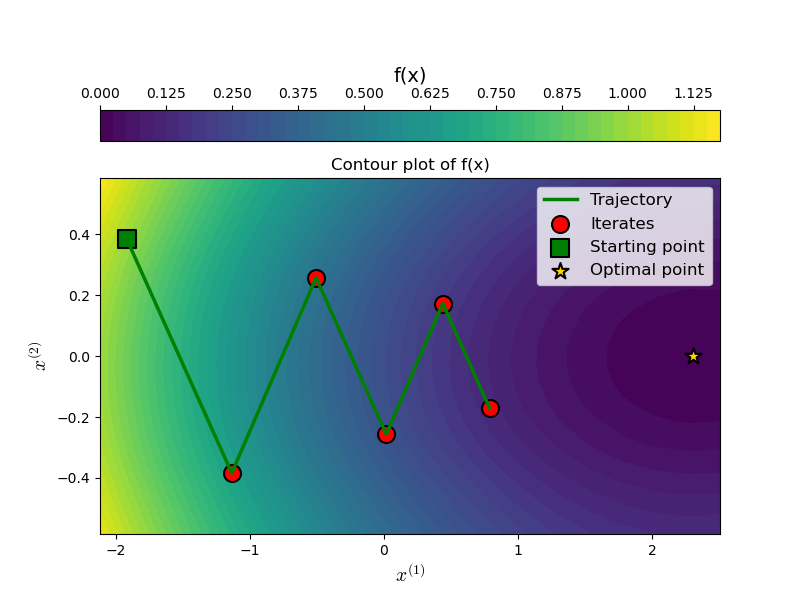

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure and axes (2D now)
fig, ax = plt.subplots(figsize=(8,6))

# Contour plot
cont = ax.contourf(X, Y, FX, levels=50, cmap='viridis')

# Extract x, y from x_list_evaluated
x_pts = np.array([arr[0] for arr in x_list_evaluated])
y_pts = np.array([arr[1] for arr in x_list_evaluated])

# Overlay evaluated points (more visible)
ax.plot(
    x_pts[:-1],
    y_pts[:-1],
    color='green',
    linewidth=2.5,
    label='Trajectory'
)
ax.scatter(
    x_pts[:-1],
    y_pts[:-1],
    color='red',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    marker='o',
    label='Iterates'
)
ax.scatter(
    x_pts[0],
    y_pts[0],
    color='green',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    marker='s',
    label='Starting point'
)
ax.scatter(
    x_pts[-1],
    y_pts[-1],
    color='gold',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    marker='*',
    label='Optimal point'
)

# Color bar
cbar = fig.colorbar(cont, ax=ax, orientation='horizontal', location='top', pad=0.08, label='f(x)')

# Labels
ax.set_xlabel(r'$x^{(1)}$')
ax.set_ylabel(r'$x^{(2)}$')

# Title
ax.set_title('Contour plot of f(x)')

ax.legend()

plt.show()

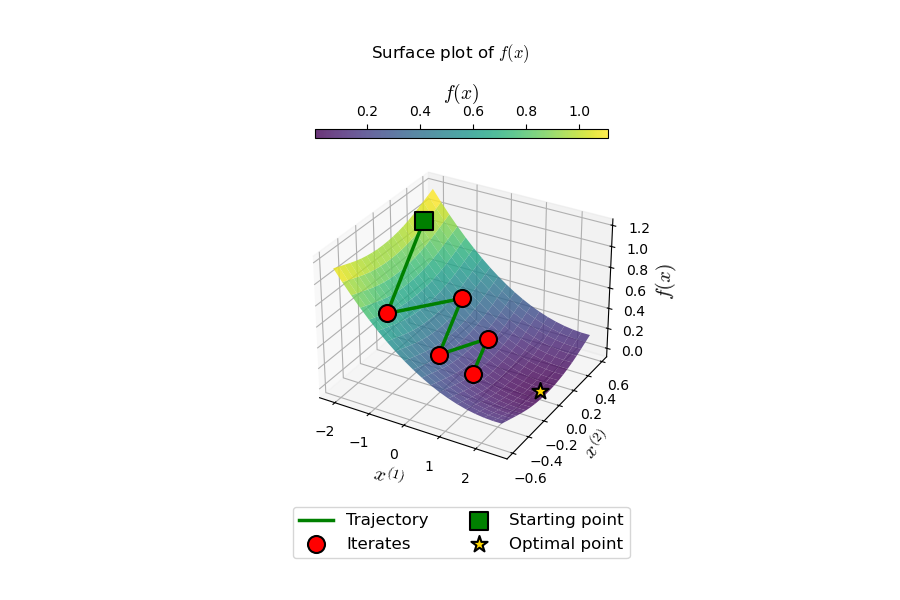

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create figure and 3D axes
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)

# Plot the surface
surf = ax.plot_surface(
    X, Y, FX,
    cmap='viridis',
    edgecolor='none',
    alpha=0.8,
    zorder=0
)

# Extract x, y from x_list_evaluated
x_pts = np.array([arr[0] for arr in x_list_evaluated])
y_pts = np.array([arr[1] for arr in x_list_evaluated])
z_pts = np.array(f_list_evaluated)

# Overlay evaluated points (more visible)
ax.plot(
    x_pts[:-1],
    y_pts[:-1],
    z_pts[:-1],
    color='green',
    linewidth=2.5,
    zorder=5,
    label='Trajectory'
)
ax.scatter(
    x_pts[:-1],
    y_pts[:-1],
    z_pts[:-1],
    color='red',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    depthshade=False,
    marker='o',
    zorder=10,
    label='Iterates'
)
ax.scatter(
    x_pts[0],
    y_pts[0],
    z_pts[0],
    color='green',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    depthshade=False,
    marker='s',
    zorder=10,
    label='Starting point'
)
ax.scatter(
    x_pts[-1],
    y_pts[-1],
    z_pts[-1],
    color='gold',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    depthshade=False,
    marker='*',
    zorder=10,
    label='Optimal point'
)

# Add color bar
fig.colorbar(surf, ax=ax, orientation='horizontal', location='top', pad=0.02, shrink=0.42, aspect=30, label='$f(x)$')

# Labels
ax.set_xlabel(r'$x^{(1)}$')
ax.set_ylabel(r'$x^{(2)}$')
ax.set_zlabel('$f(x)$')

# Title
fig.suptitle('Surface plot of $f(x)$', y=0.93)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2, borderaxespad=0.)
fig.subplots_adjust(bottom=0.2, top=0.87)

plt.show()